In [ ]:
!pip install kaggle transformers datasets evaluate rouge_score --quiet

  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 84.1/84.1 kB 4.3 MB/s eta 0:00:00


In [ ]:
!pip install --upgrade transformers accelerate datasets --quiet


     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.0/44.0 kB 2.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.0/12.0 MB 73.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 511.6/511.6 kB 16.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 47.7/47.7 MB 18.7 MB/s eta 0:00:00


In [ ]:
from google.colab import files
files.upload()   # upload kaggle.json
!mkdir -p ~/.kaggle && mv kaggle.json ~/.kaggle/ && chmod 600 ~/.kaggle/kaggle.json

Saving kaggle.json to kaggle.json


In [ ]:
!kaggle datasets download -d pranjalverma08/sec-edgar-annual-financial-filings-2021
!unzip sec-edgar-annual-financial-filings-2021.zip -d edgar_data

Dataset URL: https://www.kaggle.com/datasets/pranjalverma08/sec-edgar-annual-financial-filings-2021
License(s): CC0-1.0
  0% 0.00/62.8M [00:00<?, ?B/s]
100% 62.8M/62.8M [00:00<00:00, 715MB/s]
Archive:  sec-edgar-annual-financial-filings-2021.zip
  inflating: edgar_data/extracted/1001601_10K_2020_0001493152-21-008913.json  
  inflating: edgar_data/extracted/1002517_10K_2021_0001002517-21-000052.json  
  inflating: edgar_data/extracted/1013462_10K_2020_0001013462-21-000009.json  
  inflating: edgar_data/extracted/1013857_10K_2020_0001013857-21-000032.json  
  inflating: edgar_data/extracted/1015739_10K_2020_0001564590-21-006373.json  
  inflating: edgar_data/extracted/1017655_10K_2020_0001654954-21-003649.json  
  inflating: edgar_data/extracted/1019034_10K_2020_0001437749-21-007486.json  
  inflating: edgar_data/extracted/1019671_10K_2021_0001564590-21-018886.json  
  inflating: edgar_data/extracted/1021435_10K_2020_0001493152-21-007517.json  
  inflating: edgar_data/extracted/1022505_1

In [ ]:
from bs4 import BeautifulSoup

path = "edgar_data/raw/1001601_10K_2020_0001493152-21-008913.htm"

with open(path, "r", encoding="latin-1") as f:
    html = f.read()

soup = BeautifulSoup(html, "lxml")
text = soup.get_text(separator=" ")


In [ ]:
import os
import pandas as pd
from bs4 import BeautifulSoup
import re

folder = "edgar_data/raw"
records = []

def clean_text(t):
    t = re.sub(r'\s+', ' ', t)            # collapse whitespace
    t = re.sub(r'[\x00-\x1F\x7F]', '', t) # remove control chars
    return t.strip()

def extract_mdna_section(text):
    """
    Extract the 'Management’s Discussion and Analysis' (MD&A) section.
    If not found, fall back to the first 5000 characters.
    """
    lowered = text.lower()

    # Common patterns for MD&A section title
    patterns = [
        "management’s discussion and analysis",
        "management's discussion and analysis",
        "managements discussion and analysis",
        "md&a"
    ]

    start = -1
    for p in patterns:
        idx = lowered.find(p)
        if idx != -1:
            start = idx
            break

    # Could not find MD&A → return first 5000 chars
    if start == -1:
        return text[:5000]

    # Clip MD&A section length
    end = start + 30000   # takes approx. 2–3 pages of MD&A
    return text[start:end]

for filename in os.listdir(folder):
    path = os.path.join(folder, filename)

    # Read HTML content
    try:
        with open(path, 'r', encoding='latin-1') as f:
            html = f.read()
    except:
        continue

    # Parse and extract text
    soup = BeautifulSoup(html, "lxml")
    raw_text = soup.get_text(separator=" ")
    raw_text = clean_text(raw_text)
    cleaned = extract_mdna_section(raw_text)

    records.append({
        "filename": filename,
        "text": cleaned
    })


df = pd.DataFrame(records)
df.head()
print("Loaded filings:", len(df))


/tmp/ipython-input-2689692466.py:55: XMLParsedAsHTMLWarning: It looks like you're using an HTML parser to parse an XML document.

Assuming this really is an XML document, what you're doing might work, but you should know that using an XML parser will be more reliable. To parse this document as XML, make sure you have the Python package 'lxml' installed, and pass the keyword argument `features="xml"` into the BeautifulSoup constructor.

If you want or need to use an HTML parser on this document, you can make this warning go away by filtering it. To do that, run this code before calling the BeautifulSoup constructor:

    from bs4 import XMLParsedAsHTMLWarning
    import warnings

    warnings.filterwarnings("ignore", category=XMLParsedAsHTMLWarning)

  soup = BeautifulSoup(html, "lxml")


Loaded filings: 191


In [ ]:
import re

def generate_pseudo_summary(text):
    sentences = re.split(r'(?<=[.!?]) +', text)
    return ' '.join(sentences[:3])

df["summary"] = df["text"].apply(generate_pseudo_summary)
df[["filename", "summary"]].head()


,filename,summary
0,1810806_10K_2020_0001810806-21-000052.htm,Management’s Discussion and Analysis of Financ...
1,935036_10K_2020_0000935036-21-000014.htm,Management’s Discussion and Analysis of Financ...
2,1725057_10K_2020_0001564590-21-009508.htm,Management’s Discussion and Analysis of Financ...
3,1682325_10K_2020_0001558370-21-001283.htm,Management’s Discussion and Analysis of Financ...
4,746210_10K_2020_0000746210-21-000024.htm,Management’s Discussion and Analysis of Financ...


In [ ]:
from datasets import Dataset
from transformers import AutoTokenizer

# Convert pandas DF → HuggingFace dataset
dataset = Dataset.from_pandas(df[['text', 'summary']])

tokenizer = AutoTokenizer.from_pretrained("facebook/bart-large-cnn")

def preprocess(batch):
    # Tokenize input text
    inputs = tokenizer(
        batch["text"],
        max_length=512,
        truncation=True,
        padding="max_length"
    )

    # Tokenize summaries (targets)
    with tokenizer.as_target_tokenizer():
        labels = tokenizer(
            batch["summary"],
            max_length=128,
            truncation=True,
            padding="max_length"
        )

    inputs["labels"] = labels["input_ids"]
    return inputs

tokenized = dataset.map(preprocess, batched=True, remove_columns=["text", "summary"])
tokenized = tokenized.train_test_split(test_size=0.1)

tokenized


Map:   0%|          | 0/191 [00:00<?, ? examples/s]

/usr/local/lib/python3.12/dist-packages/transformers/tokenization_utils_base.py:4169: UserWarning: `as_target_tokenizer` is deprecated and will be removed in v5 of Transformers. You can tokenize your labels by using the argument `text_target` of the regular `__call__` method (either in the same call as your input texts if you use the same keyword arguments, or in a separate call.
  warnings.warn(


DatasetDict({
    train: Dataset({
        features: ['input_ids', 'attention_mask', 'labels'],
        num_rows: 171
    })
    test: Dataset({
        features: ['input_ids', 'attention_mask', 'labels'],
        num_rows: 20
    })
})

In [ ]:
import os
os.environ["WANDB_DISABLED"] = "true"


In [ ]:
from transformers import AutoModelForSeq2SeqLM, DataCollatorForSeq2Seq, Seq2SeqTrainer, Seq2SeqTrainingArguments

model = AutoModelForSeq2SeqLM.from_pretrained("facebook/bart-large-cnn")

data_collator = DataCollatorForSeq2Seq(tokenizer, model=model)

training_args = Seq2SeqTrainingArguments(
    output_dir="bart_edgar",
    eval_strategy="epoch",                 # or "steps"
    learning_rate=2e-5,
    per_device_train_batch_size=1,
    per_device_eval_batch_size=1,
    gradient_accumulation_steps=8,
    num_train_epochs=5,                   # increased epochs
    predict_with_generate=True,
    fp16=True,                             # REQUIRED for T4 GPU
    logging_dir="./logs",
    logging_steps=1,                       # log every step
    save_strategy="epoch",                 # optional: save model each epoch
)


trainer = Seq2SeqTrainer(
    model=model,
    args=training_args,
    train_dataset=tokenized["train"],
    eval_dataset=tokenized["test"],
    tokenizer=tokenizer,
    data_collator=data_collator,
)

trainer.train()

Using the `WANDB_DISABLED` environment variable is deprecated and will be removed in v5. Use the --report_to flag to control the integrations used for logging result (for instance --report_to none).
/tmp/ipython-input-4132094434.py:23: FutureWarning: `tokenizer` is deprecated and will be removed in version 5.0.0 for `Seq2SeqTrainer.__init__`. Use `processing_class` instead.
  trainer = Seq2SeqTrainer(


Epoch,Training Loss,Validation Loss
1,0.554300,0.498802
2,0.117500,0.189987
3,0.094600,0.126819
4,0.097000,0.093632
5,0.098300,0.091416


/usr/local/lib/python3.12/dist-packages/transformers/modeling_utils.py:3918: UserWarning: Moving the following attributes in the config to the generation config: {'max_length': 142, 'min_length': 56, 'early_stopping': True, 'num_beams': 4, 'length_penalty': 2.0, 'no_repeat_ngram_size': 3, 'forced_bos_token_id': 0}. You are seeing this warning because you've set generation parameters in the model config, as opposed to in the generation config.
  warnings.warn(


TrainOutput(global_step=110, training_loss=0.652536732906645, metrics={'train_runtime': 1164.8015, 'train_samples_per_second': 0.734, 'train_steps_per_second': 0.094, 'total_flos': 926437217402880.0, 'train_loss': 0.652536732906645, 'epoch': 5.0})

In [ ]:
from evaluate import load
import numpy as np

metric = load("rouge")

preds = trainer.predict(tokenized["test"])
decoded_preds = tokenizer.batch_decode(preds.predictions, skip_special_tokens=True)
decoded_labels = tokenizer.batch_decode(preds.label_ids, skip_special_tokens=True)

result = metric.compute(predictions=decoded_preds, references=decoded_labels)
result


{'rouge1': np.float64(0.7940697922487414),
 'rouge2': np.float64(0.7894741306198114),
 'rougeL': np.float64(0.7941200714326369),
 'rougeLsum': np.float64(0.7962359530314902)}

In [ ]:
sample_text = df['text'].iloc[0]

# Create inputs AND move them to GPU
inputs = tokenizer(
    sample_text,
    return_tensors="pt",
    truncation=True,
    max_length=512
).to("cuda")

# Ensure model is also on GPU
model.to("cuda")

summary_ids = model.generate(
    **inputs,
    max_new_tokens=160,
    num_beams=4,
    length_penalty=2.0
)

print(tokenizer.decode(summary_ids[0], skip_special_tokens=True))


Management’s Discussion and Analysis of Financial Condition and Results of Operations 65 Item 7A. Quantitative and Qualitative Disclosures About Market Risk 84 Item 8. Financial Statements and Supplementary Data 86 Item 9. Form 10-K Summary 131 SIGNATURES 132 3 NOTE REGARDING FORWARD-LOOKING STATEMENTS


In [ ]:
all_summaries = []
batch_size = 8

model.to("cuda")

for i in range(0, len(df), batch_size):
    batch = df['text'][i:i+batch_size].tolist()

    inputs = tokenizer(
        batch,
        return_tensors="pt",
        truncation=True,
        max_length=256,
        padding=True
    ).to("cuda")

    summary_ids = model.generate(
        **inputs,
        max_new_tokens=120,
        num_beams=1      # MUCH faster
    )

    decoded = tokenizer.batch_decode(summary_ids, skip_special_tokens=True)
    all_summaries.extend(decoded)

df['generated_summary'] = all_summaries
df.to_csv("all_filing_summaries.csv", index=False)


In [ ]:
import os
os.makedirs("summaries", exist_ok=True)

for i, row in df.iterrows():
    with open(f"summaries/{row['filename']}_summary.txt", "w") as f:
        f.write(row['generated_summary'])


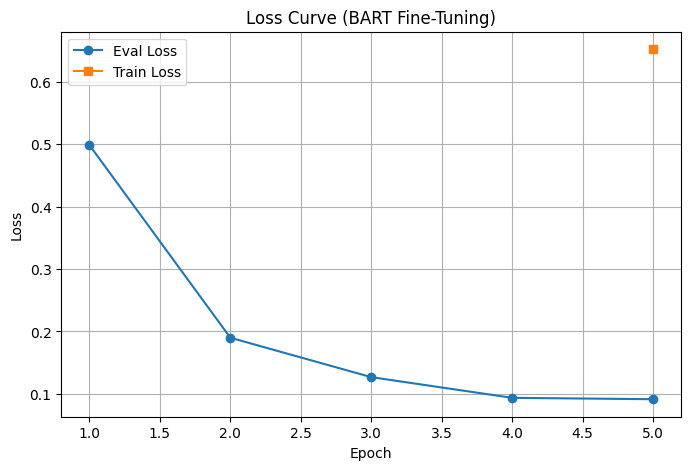

In [ ]:
import matplotlib.pyplot as plt

eval_epochs = []
eval_losses = []
train_epochs = []
train_losses = []

for log in trainer.state.log_history:
    if "eval_loss" in log:
        eval_epochs.append(log["epoch"])
        eval_losses.append(log["eval_loss"])
    if "train_loss" in log:
        train_epochs.append(log["epoch"])
        train_losses.append(log["train_loss"])

plt.figure(figsize=(8,5))

# Plot eval loss
plt.plot(eval_epochs, eval_losses, marker='o', label="Eval Loss")

# Plot train loss (will be only one point unless logging_steps was used)
plt.plot(train_epochs, train_losses, marker='s', label="Train Loss")

plt.title("Loss Curve (BART Fine-Tuning)")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.grid(True)
plt.legend()
plt.savefig("loss_curve.png", dpi=300)
plt.show()
